# BraTS 2020 Brain Tumor Segmentation Project
## UNET & Swin UNETR

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
UNET = False

### 1.0.1 Libraries and Dependencies

In [ ]:
!pip install monai
!pip install torchmetrics
# !pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.3 MB/s eta 0:00:00


In [ ]:
import gc
import os
import osqp
import math
import torch
import random
import kagglehub
import numpy as np
import torch.nn as nn
import nibabel as nib
import matplotlib.pyplot as plt
from monai.networks.nets import UNet, SwinUNETR
from monai.inferers import SlidingWindowInferer
from monai.utils import set_determinism
from sklearn.model_selection import KFold
from monai.losses import DiceLoss, DiceCELoss
from monai.data import Dataset as MonaiDataset
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    RandCropByPosNegLabeld, ToTensord, MapLabelValued, CenterSpatialCropd)
from monai.metrics import MeanIoU, HausdorffDistanceMetric
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torchmetrics.classification import MulticlassJaccardIndex
print(f"Cuda availability: {torch.cuda.is_available()}")

Cuda availability: True


### 1.0.2 Reproducibility Settings

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # MONAI specific determinism
    set_determinism(seed=seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed and MONAI determinism set to: {seed}")

set_seed(42)

Random seed and MONAI determinism set to: 42


# 1. Data Acquisition and Preprocessing

## 1.1 Dataset Download and Initial Inspection

### 1.1.1 Dataset Download

In [ ]:
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Exists:", os.path.exists(path))
print("Path to dataset files:", path)
print("Contents:", os.listdir(path))


100%|██████████| 4.16G/4.16G [00:23<00:00, 194MB/s]

Extracting files...


Using device: cuda
Exists: True
Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/versions/1
Contents: ['BraTS2020_ValidationData', 'BraTS2020_TrainingData']


### 1.1.2 File Format and Content Checks

### File Format Check

In [ ]:
print("Opening both Folders")
train_dir = os.path.join(path, "BraTS2020_TrainingData")
val_dir = os.path.join(path, "BraTS2020_ValidationData")

train_folder = os.listdir(train_dir)
val_folder = os.listdir(val_dir)

print("BraTS2020_TrainingData:", train_folder)
print("BraTS2020_ValidationData:", val_folder)

Opening both Folders
BraTS2020_TrainingData: ['MICCAI_BraTS2020_TrainingData']
BraTS2020_ValidationData: ['MICCAI_BraTS2020_ValidationData']


#### 1.1.2.1 Modality Structure Verification

#### 1.1.2.2 Training Dataset Selection

In [ ]:
train_dir = os.path.join(path,"BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")
train_subjects = sorted(os.listdir(train_dir))
print("Total files in MICCAI_BraTS2020_TrainingData:", len(train_subjects))
# Pick one subject
train_subject = train_subjects[0]
train_subject_path = os.path.join(train_dir, train_subject)
files_train = os.listdir(train_subject_path)
print("Training data subject file content:", files_train)

Total files in MICCAI_BraTS2020_TrainingData: 371
Training data subject file content: ['BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t2.nii', 'BraTS20_Training_001_t1ce.nii']


## 1.2 Data List Preparation and Preprocessing Transforms

### Data List Prepration

In [ ]:
def check_valid(Base_dir, subject_id):
  filepath = os.path.join(Base_dir, subject_id)
  if not os.path.isdir(filepath):
    return False

  required_files = [
      f"{subject_id}_t1.nii",
      f"{subject_id}_t1ce.nii",
      f"{subject_id}_t2.nii",
      f"{subject_id}_flair.nii",
      f"{subject_id}_seg.nii"]

  for f in required_files:
    if not os.path.exists(os.path.join(filepath, f)):
      print(f"Warning: Missing file {f} for subject {subject_id}. Excluding subject.")
      return False
  return True

In [ ]:
def BraTSDataset(data_dir, seed=42, size=None):
    subjects = [
    s for s in sorted(os.listdir(data_dir))
    if check_valid(data_dir, s)
    ]
    print("Total valid training data subjects:", len(subjects))
    data_list = []
    for s in subjects:
        subj_path = os.path.join(data_dir, s)
        data_list.append({
            "image": [
                os.path.join(subj_path, f"{s}_flair.nii"),
                os.path.join(subj_path, f"{s}_t1.nii"),
                os.path.join(subj_path, f"{s}_t1ce.nii"),
                os.path.join(subj_path, f"{s}_t2.nii")
            ],
            "label": os.path.join(subj_path, f"{s}_seg.nii"),
            "case_id": s
        })
    random.Random(seed).shuffle(data_list)
    print("Total subjects after shuffling:", len(data_list))

    if size is not None and size < len(data_list):
        data_list = data_list[:size]
        print("Total selected subjects:", len(data_list))

    return data_list

In [ ]:
def get_fold_data(data_list, fold_idx, n_splits=5, seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    all_splits = list(kf.split(data_list))
    train_idx, val_idx = all_splits[fold_idx]

    train_data = [data_list[i] for i in train_idx]
    val_data = [data_list[i] for i in val_idx]

    return train_data, val_data

In [ ]:
full_data_list = BraTSDataset(train_dir, seed=42, size=100)
print(f"Total subjects Loaded: {len(full_data_list)} cases")
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

Total valid training data subjects: 368
Total subjects after shuffling: 368
Total selected subjects: 100
Total subjects Loaded: 100 cases


### 1.2.1 MONAI Transforms Configuration

#### Applying MONAI Transforms
we will use transforms for preprocessing:

1.   LoadImaged is used for loading a dictionary of images with keys 'image' and 'label'.
2.   EnsureChannelFirstd is used for correcting dimensions.
1.   MapLabelValued for continous labeling.
2.   NormalizeIntensityd replaces manual z-score normalization.
1.   RandSpatialCropd is used for cropping images of train dataset.
2.   ToTensord is used for converting images to tensors.
1.   CenterSpatialCropd is cropping for validation and test dataset.


#### 1.2.1.1 Application to Train & Validation Datasets

In [ ]:
if UNET:
  train_transforms = Compose([
      LoadImaged(keys=["image", "label"]),
      EnsureChannelFirstd(keys=["image", "label"]),
      # BraTS label, Map 4 to 3 to make them sequential.
      MapLabelValued(keys="label", orig_labels=[4], target_labels=[3]),
      NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
      RandCropByPosNegLabeld(keys=["image", "label"],label_key="label",spatial_size=(128, 128, 128),
          pos=1,neg=1,
          num_samples=4,
          image_key="image",
          image_threshold=0
      ),
      ToTensord(keys=["image", "label"]),
  ])
  val_transforms = Compose([
      LoadImaged(keys=["image", "label"]),
      EnsureChannelFirstd(keys=["image", "label"]),
      MapLabelValued(keys="label", orig_labels=[4], target_labels=[3]),
      NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
      # CenterSpatialCropd(keys=["image", "label"], roi_size=(128, 128, 128)),
      ToTensord(keys=["image", "label"]),
  ])
  print("UNET Transforms")
else:
  train_transforms = Compose([
      LoadImaged(keys=["image","label"]),
      EnsureChannelFirstd(keys=["image","label"]),
      MapLabelValued(keys="label", orig_labels=[4], target_labels=[3]),
      NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
      RandCropByPosNegLabeld(keys=["image","label"], label_key="label",
          spatial_size=(128, 128, 128),
          pos=1, neg=1,
          num_samples=4,
          image_key="image",
          image_threshold=0),
      ToTensord(keys=["image","label"]),
  ])
  val_transforms = Compose([
      LoadImaged(keys=["image","label"]),
      EnsureChannelFirstd(keys=["image","label"]),
      MapLabelValued(keys="label", orig_labels=[4], target_labels=[3]),
      NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
      # CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
      ToTensord(keys=["image","label"]),
  ])
  print("Swin UNETR Transforms")

Swin UNETR Transforms


## 1.3 Preprocessing Verification and Visualization

### 1.3.1 Visualizing Sample Image Modalities and Segmentation

# 2. Model Architecture and Evaluation Metrics

## 2.1 Model Architectures (UNet / SwinUNETR)

In [ ]:
val_sample_list = [full_data_list[1]]
val_ds_vis = MonaiDataset(data=val_sample_list, transform=val_transforms)
val_loader_vis = DataLoader(val_ds_vis, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
val_batch_raw = next(iter(val_loader_vis))

In [ ]:
val_batch = val_batch_raw
images_val = val_batch["image"]
masks_val = val_batch["label"]
sample_image = images_val[0]
sample_mask  = masks_val[0]
modality_names = ['FLAIR', 'T1', 'T1ce', 'T2']

In [ ]:
print(f"\nBatch verification:")
print(f"  Image batch shape : {sample_image.shape}")   # expect (batch_size, channels, H, W, D)
print(f"  Mask batch shape  : {sample_mask.shape}")
print(f"  Image dtype       : {sample_image.dtype}")
print(f"  Mask dtype        : {sample_mask.dtype}")
print(f"  Image value range : [{sample_image.min():.2f}, {sample_image.max():.2f}]")
print(f"  Mask value range  : [{sample_mask.min():.2f}, {sample_mask.max():.2f}]")
print(f"  Unique mask labels: {torch.unique(sample_mask)}")  # expect [0,1,2,3]
print(f"  mean:               {sample_image.mean()}")
print(f"  standard deviation: {sample_image.std()}")


Batch verification:
  Image batch shape : torch.Size([4, 240, 240, 155])
  Mask batch shape  : torch.Size([1, 240, 240, 155])
  Image dtype       : torch.float32
  Mask dtype        : torch.float32
  Image value range : [-5.32, 10.02]
  Mask value range  : [0.00, 3.00]
  Unique mask labels: tensor([0., 1., 2., 3.])
  mean:               2.160294609865332e-09
  standard deviation: 0.3869902193546295


In [ ]:
mask_val_np = sample_mask.cpu().numpy()
if mask_val_np.ndim == 4:        # (C,H,W,D) where C=1
    mask_val_np = mask_val_np.squeeze(0)
tumour_slices_val = np.where(mask_val_np.any(axis=(0,1)))[0]

if len(tumour_slices_val) > 0:
    slice_idx_val = int(tumour_slices_val[len(tumour_slices_val)//2]) # middle tumour slice
    print("Validation tumour slice:", slice_idx_val)
else:
    slice_idx_val = mask_val_np.shape[2] // 2  # default to center slice
    print("No tumour slices found! Using center slice for validation:", slice_idx_val)

Validation tumour slice: 78


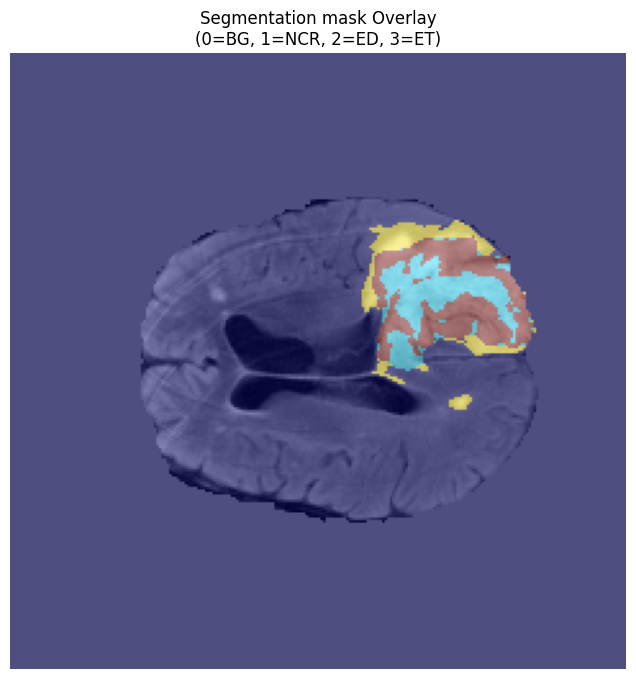

In [ ]:
# Overlay the segmentation mask on the FLAIR MRI image for visual verification
fig, axes = plt.subplots(1, figsize=(8, 8))
plt.imshow(sample_image[0,:,:,slice_idx_val].cpu().numpy(), cmap="gray")
axes.imshow(mask_val_np[:, :, slice_idx_val], alpha=0.4, cmap='jet')
axes.set_title('Segmentation mask Overlay\n(0=BG, 1=NCR, 2=ED, 3=ET)')
axes.axis('off')
plt.show()

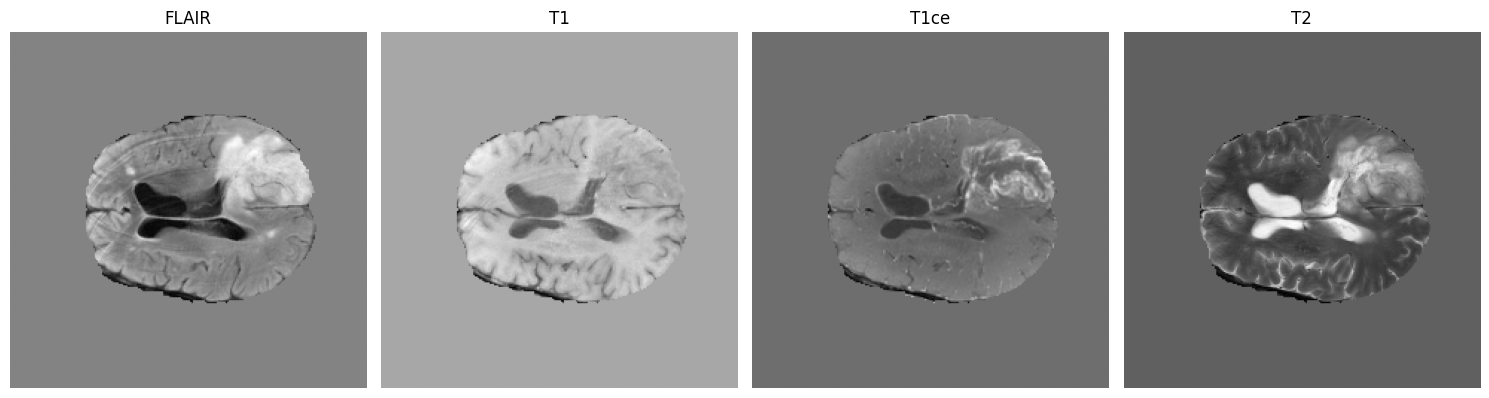

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(sample_image[i, :, :, slice_idx_val].cpu().numpy(), cmap='gray')
    axes[i].set_title(modality_names[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

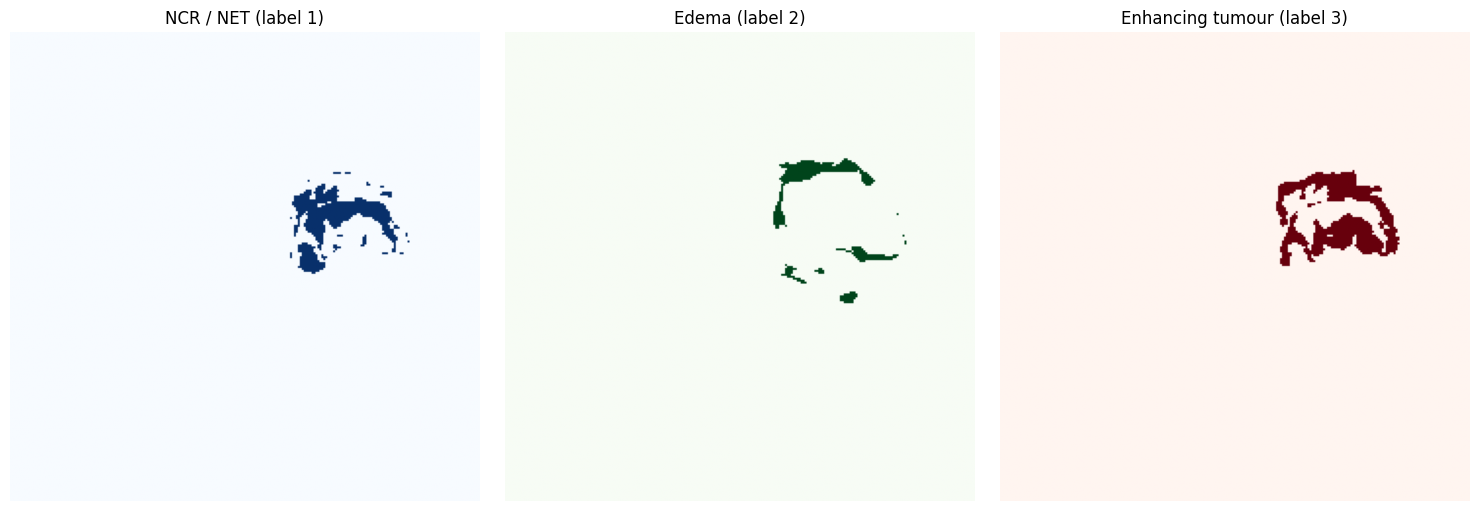

In [ ]:
# Visualize the three tumor classes separately
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['NCR / NET (label 1)', 'Edema (label 2)', 'Enhancing tumour (label 3)']
cmap = ['Blues', 'Greens', 'Reds']
for i in range(3):
    axes[i].imshow((mask_val_np == (i+1))[:, :, slice_idx_val], cmap=cmap[i])
    axes[i].set_title(labels[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2.2 Evaluation Metrics and Loss Functions

In [ ]:
def compute_class_weights(data_list, num_classes=4, device='cpu', eps=1e-8, bg=False):
    class_counts = np.zeros(num_classes, dtype=np.float64)
    for batch in data_list:
        labels = batch["label"]
        img = nib.load(labels)
        data = img.get_fdata().astype(np.int64)
        for c in range(num_classes):
            class_counts[c] += np.sum(data == c)

    total = class_counts.sum()
    class_freq = class_counts / total

    # Inverse frequency
    class_weights = 1.0 / (class_freq + eps)

    # Clamp ET to prevent instability
    class_weights[3] = min(class_weights[3], 100.0)

    class_weights = class_weights / (class_weights[0] + eps)
    print(f"Class frequencies: {class_freq}")
    print(f"Class weights: {class_weights}")

    return torch.tensor(class_weights, dtype=torch.float32, device=device)

In [ ]:
def brats_metric_per_reg(tensor, is_logits=False):
  if is_logits:
    class_idx = tensor.argmax(dim=1, keepdim=True)
  else:
        # tensor expected either (B,1,D,H,W) or (B,D,H,W)
        if tensor.ndim == 5:
            class_idx = tensor
        elif tensor.ndim == 4:
            class_idx = tensor.unsqueeze(1)  # make (B,1,D,H,W)
        else:
            raise ValueError(f"Unexpected tensor ndim {tensor.ndim}; expected 4 or 5")
  # class_idx = class_idx.long()
  wt = (class_idx != 0)
  tc = (class_idx == 1) | (class_idx == 3)
  et = (class_idx == 3)
  brats_regions = torch.cat([wt, tc, et], dim=1).float()
  return brats_regions

### 2.2.1 Regional Dice and IoU Metrics

In [ ]:
def val_dice_metric(preds_reg, labels_reg, eps=1e-8):

    preds_reg = preds_reg.bool()
    labels_reg = labels_reg.bool()
    dims = (0, 2, 3, 4)

    intersection = (
        preds_reg & labels_reg
    ).sum(dim=dims).float()

    pred_sum = preds_reg.sum(dim=dims).float()
    label_sum = labels_reg.sum(dim=dims).float()

    dice = (
        2.0 * intersection
        / (pred_sum + label_sum + eps))
    return dice

In [ ]:
def val_iou_metric(preds_reg, labels_reg, eps = 1e-8):

  preds_reg = preds_reg.bool()
  labels_reg = labels_reg.bool()
  dims = (0, 2, 3, 4)
  intersection = (
      preds_reg & labels_reg
  ).sum(dim=dims).float()

  union = (
      preds_reg | labels_reg
  ).sum(dim=dims).float()

  iou = intersection / (union + eps)

  return iou

In [ ]:
def prs_ss(preds_reg, labels_reg, eps=1e-8):
  preds_reg = preds_reg.bool()
  labels_reg = labels_reg.bool()
  dims = (0, 2, 3, 4)
  tp = (preds_reg & labels_reg).sum(dim=dims).float()
  fp = (preds_reg & ~labels_reg).sum(dim=dims).float()
  fn = (~preds_reg & labels_reg).sum(dim=dims).float()
  precision = tp / (tp + fp + eps)
  sensitivity = tp / (tp + fn + eps)

  # pred_volume = preds_reg.sum(dim=dims).float()
  # gt_volume = labels_reg.sum(dim=dims).float()

  # volume_ratio = pred_volume / (gt_volume + eps)

  return precision, sensitivity

# 3. Training Configuration and Execution

In [ ]:
def train_one_epoch(model, train_loader, fold_idx, history, device):
  model.train()
  total_train_loss = 0
  n_train_batches = 0
  train_iou_metric.reset()
  for batch_data in train_loader:
      inputs, labels = batch_data[0]["image"].to(device), batch_data[0]["label"].to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = Sum_loss(outputs, labels)
      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      total_train_loss += loss.item()
      n_train_batches += 1

      # Apply argmax to get class predictions before updating the metric
      with torch.no_grad(): # No need to compute gradients for metric calculation
        preds_labels = outputs.argmax(dim=1)
      train_iou_metric.update(preds_labels, labels.squeeze(1))

  avg_train_loss = total_train_loss / n_train_batches
  train_cl_iou = train_iou_metric.compute()
  history["train_loss"].append(avg_train_loss)
  print(f"[Fold {fold_idx}] Train Loss: {avg_train_loss:.4f} | Train IoU per-class: {train_cl_iou}")
  return avg_train_loss, train_cl_iou

In [ ]:
def val_one_epoch(model, val_loader, fold_idx, history, device):
  model.eval()
  total_val_loss = 0
  n_val_batches = 0
  all_dice = []; all_iou = []; all_precision = []; all_sensitivity = []
  with torch.no_grad():
    for batch_data in val_loader:
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        # Use inferer for both UNET and SwinUNETR
        outputs = inferer(inputs, model)
        loss = Sum_loss(outputs, labels)
        total_val_loss += loss.item()
        n_val_batches += 1
        preds_reg = brats_metric_per_reg(outputs, is_logits=True)  # Shape: (B, 3, H, W, [D])
        labels_reg = brats_metric_per_reg(labels, is_logits=False) # Shape: (B, 3, H, W, [D])
        batch_iou = val_iou_metric(preds_reg, labels_reg)
        all_iou.append(batch_iou.cpu())

        # Dice metric for validation (regional)
        batch_dice = val_dice_metric(preds_reg, labels_reg) # shape (Batch, Regions)
        all_dice.append(batch_dice.cpu())

        precision, sensitivity = prs_ss(preds_reg, labels_reg)
        all_precision.append(precision.cpu())
        all_sensitivity.append(sensitivity.cpu())

  avg_val_loss = total_val_loss / n_val_batches
  val_reg_iou  = torch.stack(all_iou).mean(dim=0)
  val_reg_dice = torch.stack(all_dice).mean(dim=0)
  precision = torch.stack(all_precision).mean(dim=0)
  sensitivity = torch.stack(all_sensitivity).mean(dim=0)
  mean_val_dice = float(val_reg_dice.mean().cpu().numpy())
  # val_reg_iou = torch.nan_to_num(val_reg_iou, nan=0.0)
  # val_reg_dice = torch.nan_to_num(val_reg_dice, nan=0.0)

  history["val_loss"].append(avg_val_loss)
  history["val_mean_dice"].append(mean_val_dice)
  history["val_dice_per_region"].append(val_reg_dice.cpu().numpy())

  print(f"[Fold {fold_idx}] Val Loss: {avg_val_loss:.4f} | Mean Val Dice: {mean_val_dice:.4f}")
  print(f"[Fold {fold_idx}] Val Dice (WT:{val_reg_dice[0]:.4f}, TC:{val_reg_dice[1]:.4f}, ET:{val_reg_dice[2]:.4f})")
  print(f"[Fold {fold_idx}] Precision (WT:{precision[0]:.4f}, TC:{precision[1]:.4f}, ET:{precision[2]:.4f})")
  print(f"[Fold {fold_idx}] Sensitivity (WT:{sensitivity[0]:.4f}, TC:{sensitivity[1]:.4f}, ET:{sensitivity[2]:.4f})")
  print(f"[Fold {fold_idx}] Val IoU (WT:{val_reg_iou[0]:.4f}, TC:{val_reg_iou[1]:.4f}, ET:{val_reg_iou[2]:.4f})")
  return avg_val_loss, val_reg_dice, val_reg_iou, precision, sensitivity, mean_val_dice

## 3.3 K-Fold Cross-Validation Main Loop

In [ ]:
if UNET:
  print("UNET directory")
  save_dir = "/content/drive/MyDrive/brats_project/UNet"
else:
  print("Swin UNETR directory")
  save_dir = "/content/drive/MyDrive/brats_project/SwinUNETR"
if not os.path.exists(save_dir):
  os.makedirs(save_dir, exist_ok=True)
  print(f"Created directory: {save_dir}")
else:
  print(f"Saving models to: {save_dir}")

Swin UNETR directory
Created directory: /content/drive/MyDrive/brats_project/SwinUNETR


## 3.1 Global Parameters and Hyperparameters

In [ ]:
eps=1e-8
batch_size = 3
max_epochs = 50
num_classes = 4
Weight_decay=1e-4
Learning_rate = 1e-2
num_workers = 4 if torch.cuda.is_available() else 0

### 3.1.1 Class Weight Calculation

In [ ]:
class_weights = compute_class_weights(full_data_list, num_classes=num_classes, device=device, eps=eps)
class_weights = torch.clamp(class_weights, min=1.0, max=5.0).to(device)
print("Using global clamped class_weights:", class_weights)

Class frequencies: [0.99060723 0.00263486 0.00675792 0.        ]
Class weights: [  0.99999999 375.96094403 146.5844958   99.06072265]
Using global clamped class_weights: tensor([1., 5., 5., 5.], device='cuda:0')


## 3.2 Training and Validation Loop Functions

In [ ]:
torch.cuda.empty_cache()

In [ ]:
fold_results = []
print("Starting K-Fold Cross-Validation\n")
if UNET:
  print("UNET directory")
else:
  print("Swin UNETR directory")
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(full_data_list)):
  print("\n" + "↓"*80)
  print(f"Starting fold {fold_idx+1}/{n_splits}")
  train_list = [full_data_list[i] for i in train_idx]
  val_list   = [full_data_list[i] for i in val_idx]
  print(f"Current Fold {fold_idx}→→→ train cases:{len(train_list)} , val cases:{len(val_list)} ")
  print("\n" + "↓"*80)
  train_ds =  MonaiDataset(data=train_list, transform=train_transforms)
  val_ds   = MonaiDataset(data=val_list, transform=val_transforms)

  train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available(), drop_last=True)
  val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

  # class_weights = class_weights.to(device)
  CE_Loss = nn.CrossEntropyLoss(reduction='mean', ignore_index=0)
  dice_loss = DiceLoss(include_background=False, to_onehot_y=True, softmax=True, reduction='mean')

  def Sum_loss(pred_output, target, alpha=0.7, beta=0.3):
    target_ce = target.squeeze(1).long()
    l_dice = dice_loss(pred_output, target)
    l_ce = CE_Loss(pred_output, target_ce)
    return alpha * l_dice + beta * l_ce

  if UNET:
    model = UNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=4,
        channels=(32, 64, 128, 256, 320, 320),
        strides=(2, 2, 2, 2, 2),
        num_res_units=2,
        norm="instance",
        dropout=0.0,
    ).to(device)
    inferer = SlidingWindowInferer(
        roi_size=(128, 128, 128),
        sw_batch_size=2,
        overlap=0.25)
  else:
    model = SwinUNETR(
        in_channels=4,
        out_channels=4,
        feature_size=24,
        window_size=8,
        depths=(2, 2, 2, 2),
        num_heads=(3, 6, 12, 24),
        use_checkpoint=True,
        spatial_dims=3,
        ).to(device)
    inferer = SlidingWindowInferer(
        roi_size=(128, 128, 128),
        sw_batch_size=2,
        overlap=0.25)

  optimizer = torch.optim.AdamW(model.parameters(), lr=Learning_rate, weight_decay=Weight_decay, amsgrad=True)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
  train_iou_metric = MulticlassJaccardIndex(num_classes=num_classes, average=None, ignore_index=0).to(device)

  best_val_dice = -float("inf")
  best_model_path = os.path.join(save_dir, f"best_model_fold{fold_idx}.pth")
  history = {"train_loss": [], "val_loss": [], "val_mean_dice": [], "val_dice_per_region": []}
  for epoch in range(max_epochs):
        print(f"Epoch {epoch+1}/{max_epochs}")
  #...............................TRAINING LOOP..............................................
        train_loss, train_cl_iou = train_one_epoch(model, train_loader, fold_idx, history, device)
  #..............................VALIDATION LOOP.............................................
        avg_val_loss, val_reg_dice, val_reg_iou, precision, sensitivity, mean_val_dice = val_one_epoch(model, val_loader, fold_idx, history, device)
  #...................................CHECKPOINT.............................................
        #..............current checkpoint best model for fold_idx........................
        if mean_val_dice > best_val_dice:
            best_val_dice = mean_val_dice
            torch.save({
                "fold": fold_idx,
                "epoch": epoch+1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_dice": best_val_dice,
                "val_loss": avg_val_loss,
                "val_reg_dice": val_reg_dice.cpu().numpy(),
            }, best_model_path)
            print(f"[Fold {fold_idx}] Saved best model to {best_model_path}")

        scheduler.step()
        gc.collect()
  #....................Best fold model..............................
  fold_results.append({
      "fold": fold_idx,
      "best_val_dice": best_val_dice,
      "history": history,
      "best_model_path": best_model_path
  })
  print(f"Finished fold {fold_idx}. Best mean val dice: {best_val_dice:.4f}")
  del train_loader, val_loader, model, optimizer, scheduler
  torch.cuda.empty_cache()

Starting K-Fold Cross-Validation

Swin UNETR directory

↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
Starting fold 1/5
Current Fold 0→→→ train cases:80 , val cases:20 

↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
Epoch 1/50
[Fold 0] Train Loss: 0.9080 | Train IoU per-class: tensor([0.0000, 0.2344, 0.6437, 0.6269], device='cuda:0')
[Fold 0] Val Loss: 0.9000 | Mean Val Dice: 0.1421
[Fold 0] Val Dice (WT:0.1120, TC:0.0879, ET:0.2263)
[Fold 0] Precision (WT:0.0596, TC:0.0472, ET:0.1366)
[Fold 0] Sensitivity (WT:1.0000, TC:0.6919, ET:0.8335)
[Fold 0] Val IoU (WT:0.0596, TC:0.0463, ET:0.1338)
[Fold 0] Saved best model to /content/drive/MyDrive/brats_project/SwinUNETR/best_model_fold0.pth
Epoch 2/50
[Fold 0] Train Loss: 0.7418 | Train IoU per-class: tensor([0.0000, 0.4509, 0.7570, 0.7545], device='cuda:0')
[Fold 0] Val Loss: 0.8302 | Mean Val Dice: 0.2395
[Fold 0] Val Dice (WT:0.1330, TC:0.0791, ET:0.5063)
[Fold 0] Preci

## Qualitative Results - Example Segmentation Output

In [ ]:
path_to_best_model = "/content/drive/MyDrive/brats_project/SwinUNETR/best_model_fold1.pth"
print(f"Loading model from: {path_to_best_model}")

if UNET:
  model_qualitative = UNet(
      spatial_dims=3,
      in_channels=4,
      out_channels=4,
      channels=(32, 64, 128, 256, 320, 320),
      strides=(2, 2, 2, 2, 2),
      num_res_units=2,
      norm="instance",
      dropout=0.0,
  ).to(device)
  inferer = SlidingWindowInferer(
      roi_size=(128, 128, 128),
      sw_batch_size=2,
      overlap=0.25)
else:
  model_qualitative = SwinUNETR(
      in_channels=4,
      out_channels=4,
      feature_size=24,
      window_size=8,
      depths=(2, 2, 2, 2),
      num_heads=(3, 6, 12, 24),
      use_checkpoint=True,
      spatial_dims=3,
      ).to(device)
  inferer = SlidingWindowInferer(
      roi_size=(128, 128, 128),
      sw_batch_size=2,
      overlap=0.25)

# Load the best model's state dictionary
checkpoint = torch.load(path_to_best_model, map_location=device, weights_only=False)
model_qualitative.load_state_dict(checkpoint['model_state_dict'])
model_qualitative.eval()
print("Model loaded successfully and set to evaluation mode.")

Loading model from: /content/drive/MyDrive/brats_project/SwinUNETR/best_model_fold1.pth
Model loaded successfully and set to evaluation mode.


In [ ]:
with torch.no_grad():
    # inferer expects batch_size, channels, H, W, D
    input_image = sample_image.unsqueeze(0) if sample_image.ndim == 4 else sample_image
    # Perform inference
    predicted_logits = inferer(input_image.to(device), model_qualitative)
    predicted_mask = predicted_logits.argmax(dim=1).squeeze(0).cpu().numpy()

print(f"Predicted mask shape: {predicted_mask.shape}")
print(f"Unique values in predicted mask: {np.unique(predicted_mask)}")

Predicted mask shape: (240, 240, 155)
Unique values in predicted mask: [0 1 2 3]


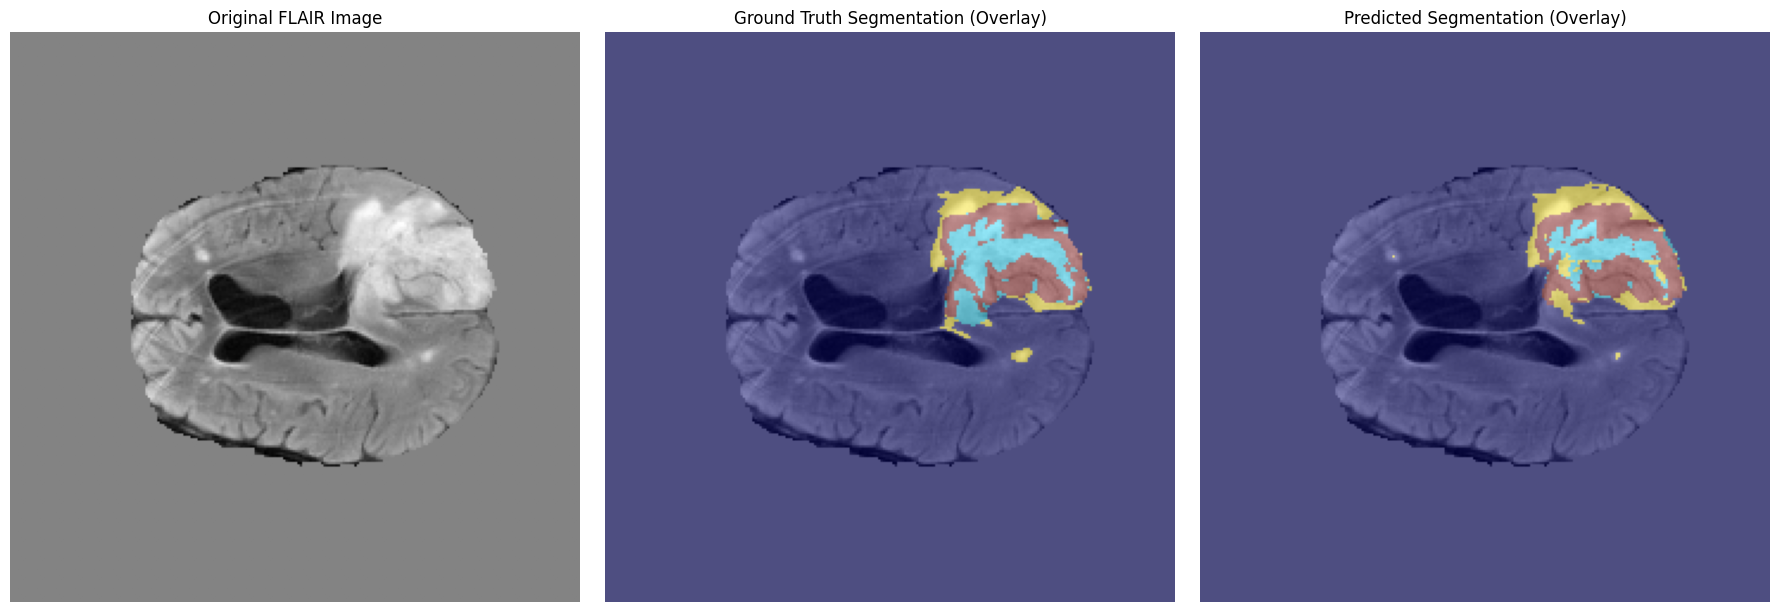

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original FLAIR image
axes[0].imshow(sample_image[0, :, :, slice_idx_val].cpu().numpy(), cmap="gray")
axes[0].set_title('Original FLAIR Image')
axes[0].axis('off')

# Ground Truth Segmentation
axes[1].imshow(sample_image[0, :, :, slice_idx_val].cpu().numpy(), cmap="gray")
axes[1].imshow(mask_val_np[:, :, slice_idx_val], alpha=0.4, cmap='jet')
axes[1].set_title('Ground Truth Segmentation (Overlay)')
axes[1].axis('off')

# Predicted Segmentation
axes[2].imshow(sample_image[0, :, :, slice_idx_val].cpu().numpy(), cmap="gray")
axes[2].imshow(predicted_mask[:, :, slice_idx_val], alpha=0.4, cmap='jet')
axes[2].set_title('Predicted Segmentation (Overlay)')
axes[2].axis('off')

plt.tight_layout()
plt.show()